# Homework Assignment: Exoplanet Detection Methods

*In this assignment, you will be attempting to model transit and radial velocity data to find the parameters of a (fake) planet. In part 1, you will be modeling this data by hand; in the (optional) part 2, you will be running some code to automatically fit this data.*

# Part 1: Fitting Data By Hand

You are a scientist looking for potential exoplanets around the star HD 1234, an M dwarf with a mass, radius, and equilibrium temperature of 0.2$M_⊙$, 0.2$R_⊙$, and 3100 K. Recently, you have been looking through light curves of the HD 1234, observed with the Transiting Exoplanet Survey Satellite (TESS), and you’ve noticed signals that may appear to be a planet!

Let's load in the data, and plot both the entire light curve (the set of stellar fluxes as a function of time) as well as a zoom-in on a single transit.

In [1]:
!pip install batman-package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 3.1 MB/s eta 0:00:00


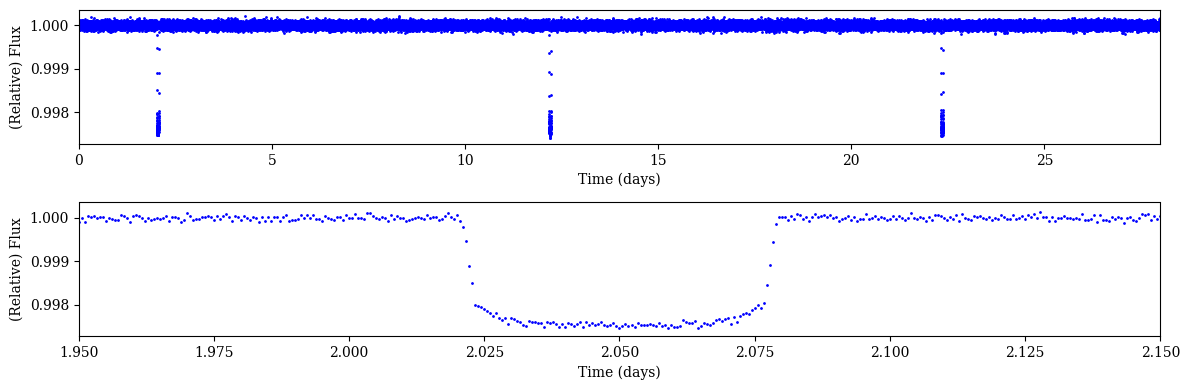

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

data = np.loadtxt('HD 1234 Light Curve.csv')
times_lc = data[0]
flux_lc = data[1]
err_lc = 0.00005

fig, ax = plt.subplots(nrows = 2, figsize = (12, 4))
ax[0].scatter(times_lc, flux_lc, c = 'blue', s = 1)
ax[0].set_xlabel('Time (days)')
ax[0].set_ylabel('(Relative) Flux')
ax[0].set_xlim(0., 28)
ax[1].scatter(times_lc, flux_lc, c = 'blue', s = 1)
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('(Relative) Flux')
ax[1].set_xlim(1.95, 2.15)
plt.tight_layout();

That sure looks like a planetary transit to me! But, of course, it might be a little difficult to figure out how big this planet is, or how close it is to its star it is -- very important things for us as astronomers to know!

But luckily for us, we can use Python packages to model this data. For the light curve data, we're going to be using the ```batman``` package, which you'll need to install: https://lkreidberg.github.io/batman/docs/html/installation.html

Install the package, and then move onto the next cell.

In [2]:
import batman

For this assignment, I've written a function that will take in planetary parameters and then model this light curve here. You can see the function below:

In [3]:
# --------------------------------------------------------------------------------------------------
# Parameters of the planet (feel free to change them around and see how the light curve changes!)
# --------------------------------------------------------------------------------------------------
M = 2.0 # the mass of the planet, in Earth masses (note: this should not affect light curves!)
R = 1.05 # the radius of the planet, in Earth radii
P = 10.004 # the period of the planet's orbit, in days
t0 = 2.052 # the epoch of the planet -- meaning the time of the first transit -- in days
inc = 90. # the inclination of the planet, in degrees
e = 0.15 # the eccentricity of the planet's orbit
w = 135 # the longitude of periastron, in degrees

In [4]:
def model_light_curve():
    # a calculation -- Kepler's third law, then converting to units of stellar radii
    a = np.cbrt(6.67e-11 * (0.2 * 1.989e30) * np.power(P * 86400., 2) / (4 * np.pi * np.pi)) / 1.39e8

    params = batman.TransitParams()
    params.t0 = t0                       #time of inferior conjunction
    params.per = P                      #orbital period
    params.rp = R * 0.0458                      #planet radius (in units of stellar radii)
    params.a = a  #semi-major axis (in units of stellar radii)
    params.inc = inc                     #orbital inclination (in degrees)
    params.ecc = 0                      #eccentricity
    params.w = 0                       #longitude of periastron (in degrees)
    params.u = [0.1, 0.3]                #limb darkening coefficients [u1, u2]
    params.limb_dark = "quadratic"       #limb darkening model

    t = np.arange(0, 28, (2 / 3600.))
    m = batman.TransitModel(params, t)    #initializes model
    flux = m.light_curve(params)
    return t, flux

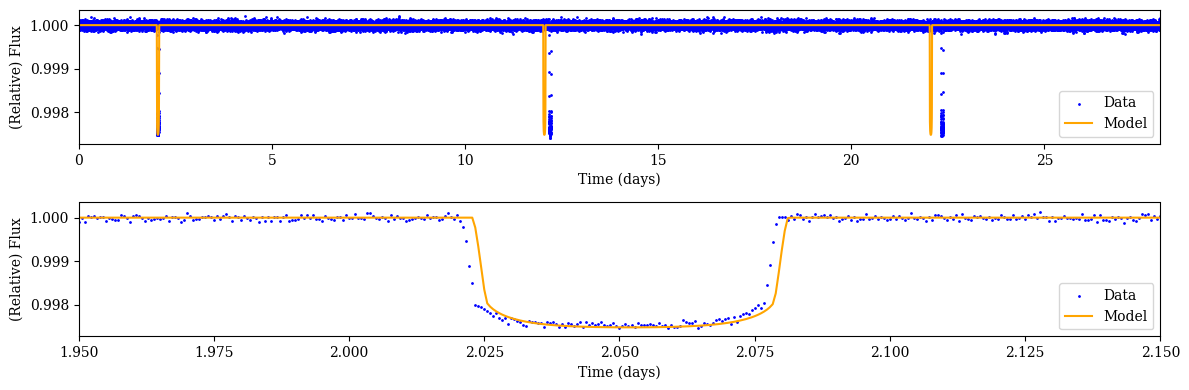

In [5]:
t_model, flux_model = model_light_curve()
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

data = np.loadtxt('HD 1234 Light Curve.csv')
times_lc = data[0]
flux_lc = data[1]

fig, ax = plt.subplots(nrows = 2, figsize = (12, 4))
ax[0].scatter(times_lc, flux_lc, c = 'blue', s = 1, label = 'Data')
ax[0].plot(t_model, flux_model, c = 'orange', label = 'Model')
ax[0].set_xlabel('Time (days)')
ax[0].set_ylabel('(Relative) Flux')
ax[0].set_xlim(0., 28)
ax[1].scatter(times_lc, flux_lc, c = 'blue', s = 1, label = 'Data')
ax[1].plot(t_model, flux_model, c = 'orange', label = 'Model')
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('(Relative) Flux')
ax[1].set_xlim(1.95, 2.15)
ax[0].legend(loc = 'lower right');
ax[1].legend(loc = 'lower right');
plt.tight_layout();

So... I missed! As you can see, it's not the WORST fit to the data of all time, but the period of the planet, the epoch, and the radius of the planet at all off. It's on you to fix it!

**Question 1:** Go back to the cell that lists off the parameters of the planet. Change them, then run that cell, then run that cell right above this one to see how the light curve changes. Repeat until you hgave a satisfactory fit to the light curve!

Luckily for us, we’ve also gotten radial velocity measurements of HD 1234 b. The radial velocities of HD 1234 as a function of time are shown below:

Text(0, 0.5, 'RV (m/s)')

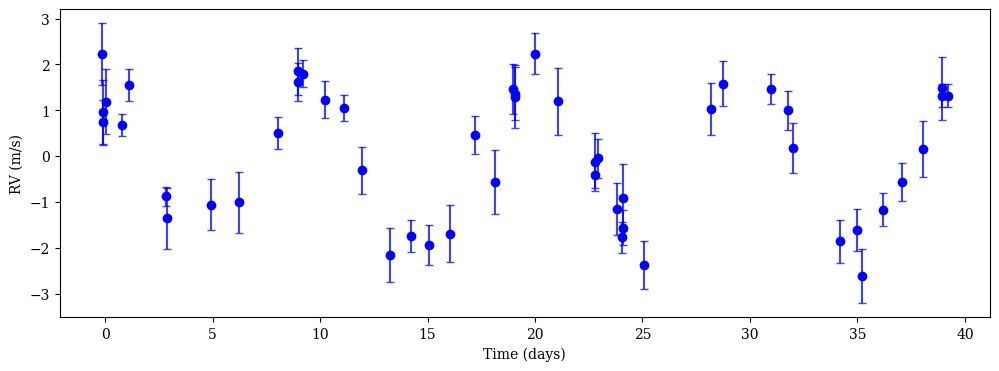

In [6]:
data_rv = np.loadtxt('HD 1234 RVs.csv')
times_rv = data_rv[0]
rv = data_rv[1]
rv_err = data_rv[2]

fig, ax = plt.subplots(figsize = (12, 4))
ax.scatter(times_rv, rv, c = 'blue')
ax.errorbar(times_rv, rv, yerr = rv_err, c = 'blue', ls = 'None', capsize = 3, alpha = 0.75)
ax.set_xlabel('Time (days)')
ax.set_ylabel('RV (m/s)')

And we do see that sort of sinusoidal shape that we expect from radial velocity signals, which is reassuring! But now, it's time to fit the data.

I've gone ahead and wrote a function below to take in parameters (from the same cell as before), and model the RVs. You can see this function below (ignore how ugly the code is, please!):

In [7]:
LARGE_ECC = 0.95

# RV
def mass_to_K(M_p, M_s, per, i, ecc):
    K = np.power(2 * np.pi * 6.67e-11 / (per * 86400.), 1./3.) * ((M_p * 6e24) * np.sin(i * np.pi / 180.) / np.power(M_s * 2e30, 2./3.)) * (1. / np.sqrt(1 - (ecc * ecc)))
    return float(K)

def f(M, E, e): # f(E) = E - esin(E) - M
    return E - e*np.sin(E) - M

def Df(E, e): #df/dE = f'(E) = 1 - ecos(E)
        return 1 - e*np.cos(E)

def ecc_anomaly(M, e, tol = 1e-10):
    E0 = M
    fn = f(M, E0, e)
    while max(np.abs(fn)) > tol: #Newton-Raohson method to find root of E - esinE - M = 0
        E_n = E0 - (f(M, E0, e)/Df(E0, e))
        E0 = E_n
        fn = f(M, E0, e)
    return E0

def phase(t, t0, P):
    return (t-t0)/P

def ecc_RV(t, e, omega, K, t0, P): ##find RV(t) for eccentric orbit
    if e > LARGE_ECC:
        e = LARGE_ECC
    if e < (-1 * LARGE_ECC):
        e = -1 * LARGE_ECC

    ph = phase(t, t0, P)
    M = 2*np.pi*ph - np.pi/2. - omega #Mean anomalies, 1
    #M = 2*np.pi*ph + np.pi/2. - omega #Mean anomalies, 2
    E = ecc_anomaly(M, e) #Eccentric anomaly
    f = 2*np.arctan((np.sqrt(1+e)/np.sqrt(1-e))*np.tan(E/2.0)) ##true anomaly
    RV_t = -K*(np.cos(f + omega) + e*np.cos(omega))
    return RV_t

def model_RVs():
    ts = np.arange(0, 40, 0.1)
    K = mass_to_K(M, 0.2, P, inc, e)
    return ts, ecc_RV(ts, e, w, K, t0, P)

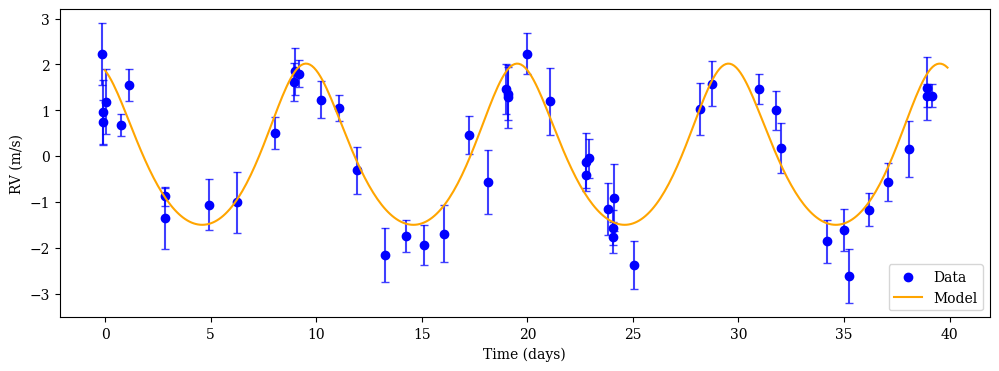

In [8]:
ts, model_rv = model_RVs()
fig, ax = plt.subplots(figsize = (12, 4))
ax.scatter(times_rv, rv, c = 'blue', label = 'Data')
ax.errorbar(times_rv, rv, yerr = rv_err, c = 'blue', ls = 'None', capsize = 3, alpha = 0.75)
ax.plot(ts, model_rv, c = 'orange', label = 'Model')
ax.set_xlabel('Time (days)')
ax.set_ylabel('RV (m/s)')
ax.legend(loc = 'lower right');

So... just like before, it's not the WORST fit in the world, but you can do better. It's on you to fix it!

**Question 2:** Go back to the cell that lists off the parameters of the planet (scroll up!). Change them, then run that cell, then run that cell right above this one to see how the RVs changes. Repeat until you hgave a satisfactory fit to the RVs, and make sure you don't mess up your fit to the light curves in the process!

Now, let's have a few questions interpreting what we did, and our results.

**Question 3:** Below (you may need to run that cell below!), I've included a plot of *mass-radius curves* for different exoplanet compositions -- meaning the relationship between mass and radius for exoplanets of different compositions. (For example, any planet, such as the Earth, which lies close to the "67% Rock, 33% Iron" line probably has a composition of 2/3 rock and 1/3 iron.)

With this in mind: what would you expect this planet to be made of?

*Answer:* The planet's mass of $2.0 \, M_{\oplus}$ and radius of $1.05 \, R_{\oplus}$ place it on the mass-radius diagram between the "67% Rock, 33% Iron" and "33% Rock, 67% Iron" curves. This indicates that the planet has a high density and a rocky interior composition with a significant iron content. Furthermore, this high density and mass suggest that the planet has the potential to generate a strong magnetic field and possesses a high surface gravity capable of retaining a substantial atmosphere.

In [9]:
from IPython.display import Image
from IPython.core.display import HTML
Image(url= "HD1234-M-R.png", width = 800)

**Question 4:** Think about what parameters you had to change to fit the light curves and the radial velocities. What parameters did you need the radial velocities to characterize? What parameters did you need the light curve to characterize?

*Answer:*
- **Radial Velocities (RV)**: These parameters are sensitive to the dynamics of the orbit. We primarily needed eccentricity ($e$) and the longitude of periastron ($w$) to accurately characterize the shape, phase, and symmetry of the radial velocity curve, which reflects the planet's gravitational influence on the star over time.
- **Light Curves**: These parameters are geometric in nature. To fit the transit data, we focused on parameters like the epoch ($t_0$), period ($P$), and planet radius ($R$). While eccentricity and longitude of periastron can affect light curves, in our specific modeling process, we found that assuming a circular orbit ($e=0, w=0$) within the model_light_curve function provided the best fit for the transit timings and shape.

# Part 2 (Optional): Fitting Data Automatically

In this section, we're going to fit the above data with our computers, instead of by hand. This has the advantage of getting much more precise values (and finding error bars on our estimates, too, in the process!)

To do this, we're going to use the package called ``emcee``: https://emcee.readthedocs.io/en/stable/user/install/

In [85]:
!pip install -U pip
!pip install -U setuptools setuptools_scm pep517
!pip install -U emcee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.4 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [setuptools_scm]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cpu requires setuptools<82, but you have setuptools 83.0.0 which is incompatible.


In [10]:
import emcee
import tqdm

We are going to try to fit seven parameters: the mass, radius, period, epoch, inclination, eccentricity, and longitude of periastron:

In [11]:
parameter_names = ['Mass (M_Earth)',
                   'Radius (R_Earth)',
                   'Period (days)',
                   'Epoch (days)',
                   'Inclination (deg)',
                   'Eccentricity',
                   'Long. of Peri. (deg)']

Below is the code for fitting for these parameters! The contents of this code are beyond the scope of this assignment, though feel more than free to try to understand how all of it works (it's very similar to the ``emcee`` tutorial: https://emcee.readthedocs.io/en/stable/tutorials/line/)

(Note that the fit uses the parameters YOU fit for by hand as an 'initial guess' for the computer! So the better you did, the better the model will do, too.)

**Question 5:** Run the cells below to fit for the parameters automatically! (Note that the final cell may take a few minutes -- it took about 5 minutes on my 2021 Macbook Pro, for reference. If you have the ``tqdm`` package installed, you'll see a little progress bar showing how fast it's running, but this isn't necessary to run the code.)

In [12]:
def log_likelihood(parameters):
    m, r, p, ep, incl, ec, lop = parameters

    # light curve model
    # a calculation -- Kepler's third law, then converting to units of stellar radii
    a = np.cbrt(6.67e-11 * (0.2 * 1.989e30) * np.power(p * 86400., 2) / (4 * np.pi * np.pi)) / 1.39e8

    params = batman.TransitParams()
    params.t0 = ep                       #time of inferior conjunction
    params.per = p                      #orbital period
    params.rp = r * 0.0458                      #planet radius (in units of stellar radii)
    params.a = a  #semi-major axis (in units of stellar radii)
    params.inc = incl                     #orbital inclination (in degrees)
    params.ecc = ec                      #eccentricity
    params.w = lop                       #longitude of periastron (in degrees)
    params.u = [0.1, 0.3]                #limb darkening coefficients [u1, u2]
    params.limb_dark = "quadratic"       #limb darkening model

    z = batman.TransitModel(params, times_lc)    #initializes model
    flux_model = z.light_curve(params)
    lc_ll = -0.5 * np.sum(np.power(flux_lc - flux_model, 2) / np.power(err_lc, 2))

    # rv model
    K = mass_to_K(m, 0.2, p, incl, ec)
    rv_model = ecc_RV(times_rv, ec, lop, K, ep, p)
    rv_ll = -0.5 * np.sum(np.power(rv - rv_model, 2) / np.power(rv_err, 2))

    return lc_ll + rv_ll

def log_prior(parameters):
    m, r, p, ep, incl, ec, lop = parameters
    if m < 0 or m > 100:
        return -np.inf
    if r < 0 or r > 100:
        return -np.inf
    if p < 0 or p > 100:
        return -np.inf
    if incl < 0 or incl > 90:
        return -np.inf
    if ec < 0 or ec > 0.9:
        return -np.inf
    if lop < 0 or lop > 360:
        return -np.inf
    return 0.0

def log_probability(parameters):
    lp = log_prior(parameters)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(parameters)

In [13]:
np.random.seed(0)
if inc > 90:
    inc_t = 180. - inc
else:
    inc_t = inc
pos = [M, R, P, t0, inc_t, e, w] + 1e-4 * np.random.randn(32, 7)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability
)

nstep = 2000
sampler.run_mcmc(pos, nstep, progress=True);

  0%|          | 0/2000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [15:43<00:00,  2.12it/s]


Now, we're going to do some diagnostics. This next cell plots the values the computer is fitting to for each of our seven parameters as a function of time. If it's working well, the rightmost ~half of the plots should not really change, where the computer has settled on the best-fit values. If that's NOT the case, change the '2000' in the cell above to a larger number (4000?) to make the computer fit the data for longer and re-run it!

Note: it's totally okay for longitude of periastron specifically to be changing a lot, as you'll see soon!

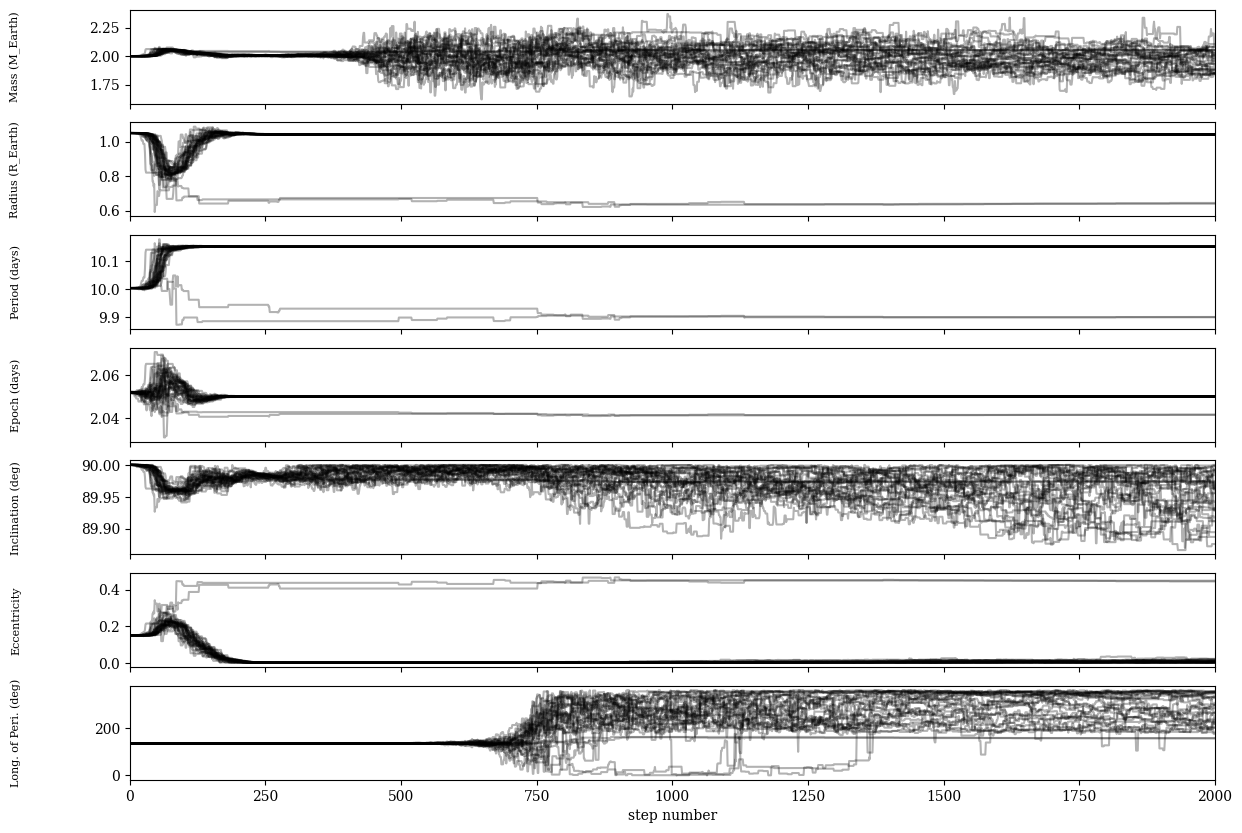

In [14]:
fig, axes = plt.subplots(7, figsize=(14, 10), sharex=True)
samples = sampler.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(parameter_names[i], size = 8)
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

Now, we can make a *corner plot* of our parameters, in order to see how your parameters can vary, or how they can correlate with each other. You'll need to install the ```corner``` package: https://corner.readthedocs.io/en/latest/install/

In [17]:
!pip install corner

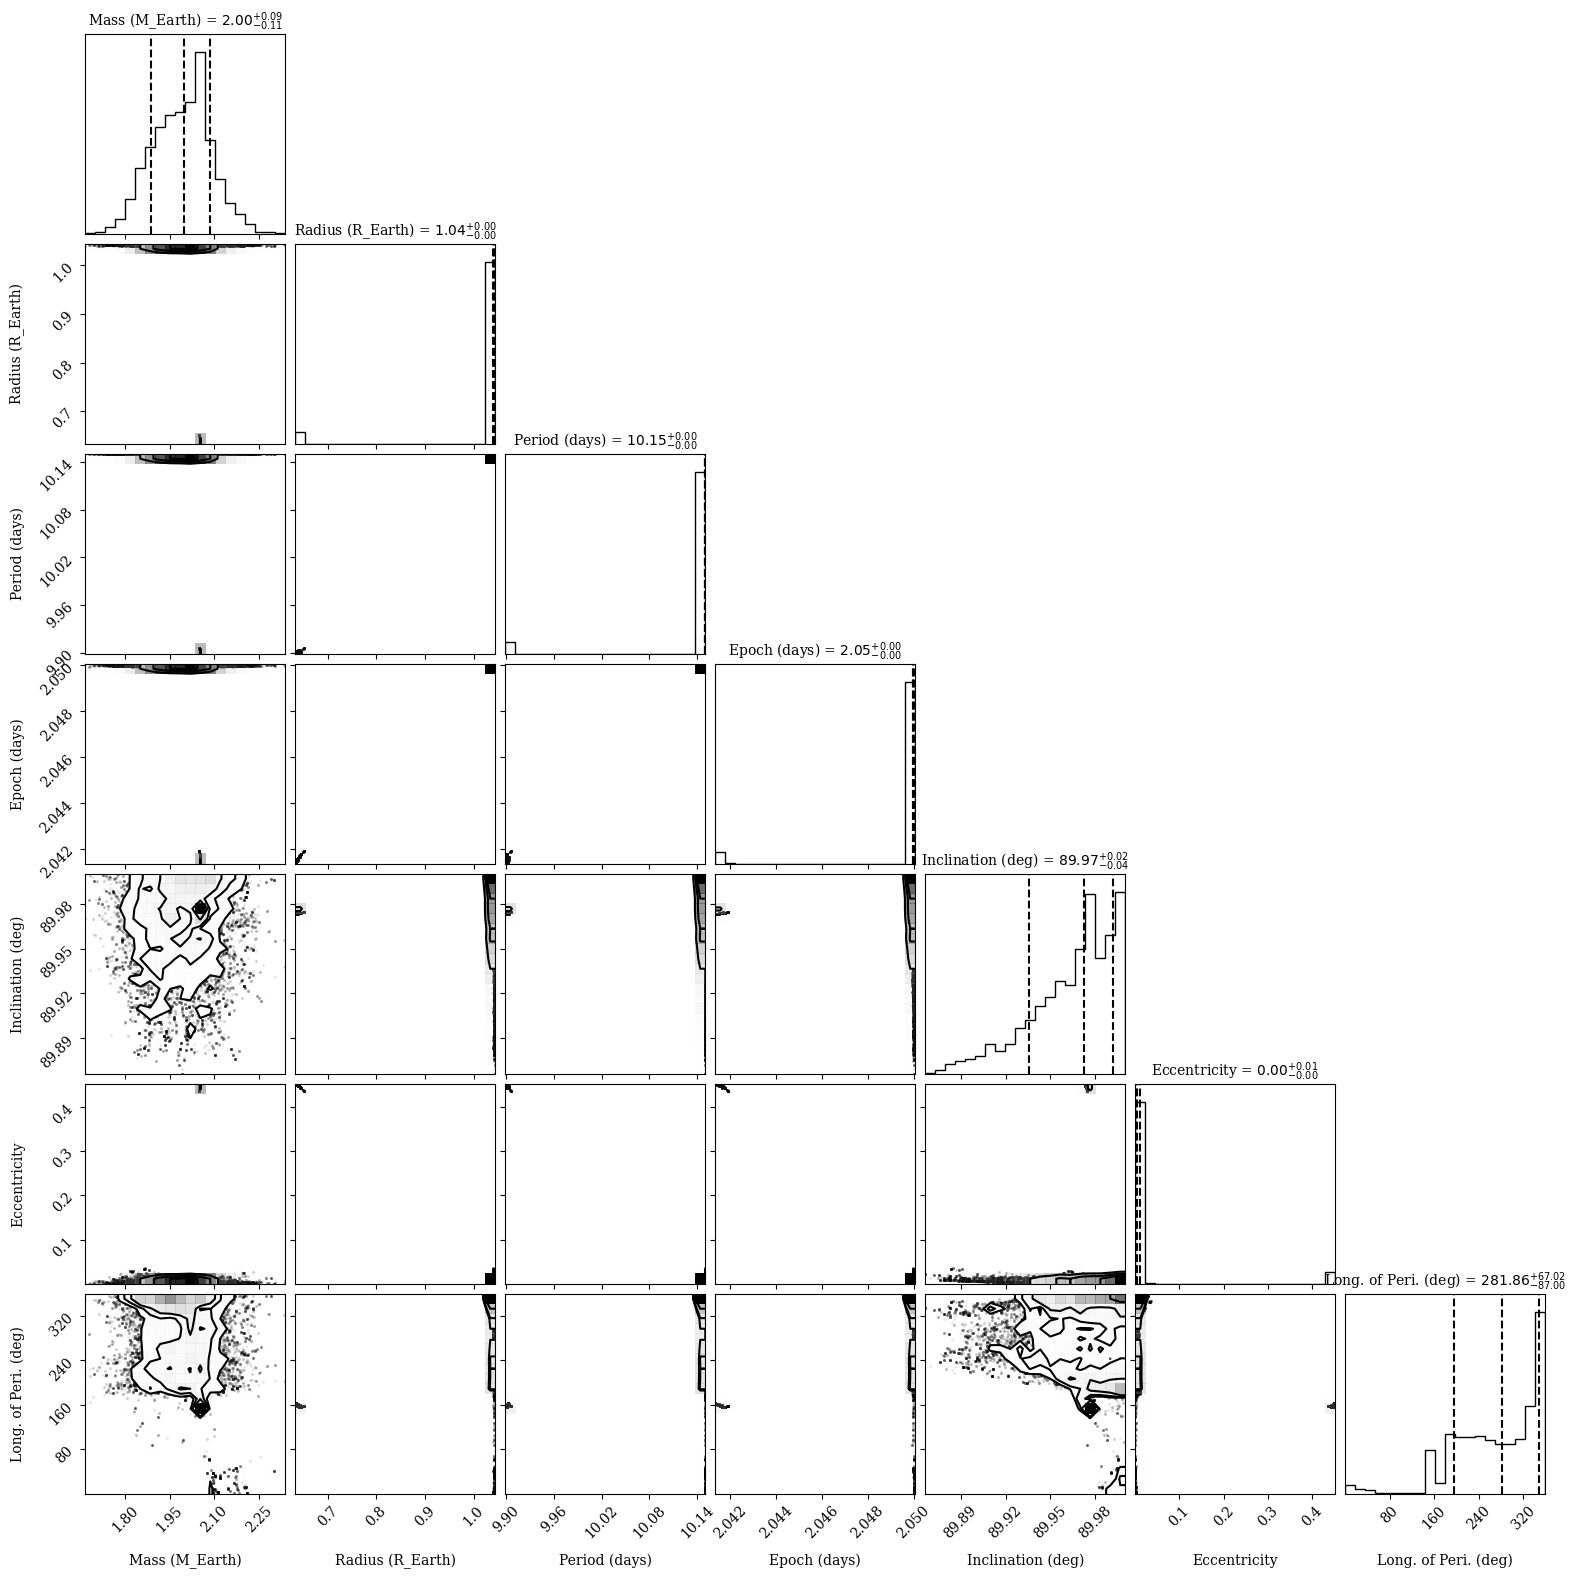

In [18]:
import corner

flat_samples = sampler.get_chain(discard = int(0.5 * nstep), flat = True)
fig = corner.corner(
    flat_samples, labels = parameter_names, quantiles = [0.159, 0.5, 0.841], show_titles = True, title_kwargs={"fontsize": 10},

);

And here's our corner plot! You can see what parameters are correlated with each other.

**Question 6:** What parameters are precisely constrained by our data, and what parameters are not precisely constrained? What parameters are correlated with each other? Why might those parameters be constrained well, or correlated with each other?

*Answer:*
- **Precisely Constrained Parameters:** Parameters such as Mass, Radius, Period, and Epoch are very precisely constrained. Their probability distributions (the histograms along the diagonal) are sharp and narrow, indicating high confidence in these values based on our transit and RV data.

- **Imprecisely Constrained Parameters:** The Longitude of Periastron (Long. of Peri.) and Inclination are less precisely constrained. Their broader distributions reflect higher uncertainty in determining the exact orientation and geometry of the orbit compared to the transit timing and mass measurements.

- **Correlations:** There is a notable correlation between Inclination and Longitude of Periastron. This occurs because both parameters influence the symmetry and duration of the transit/RV signals; essentially, the model can compensate for changes in one by adjusting the other to maintain a good fit to the data.

- **Reasoning:** Transit parameters like Period and Epoch are extremely well-constrained because they are directly tied to the precise timing of repeated transit events in the light curve. In contrast, geometric parameters like the Longitude of Periastron are often harder to constrain without high-precision RV data over multiple orbital phases, leading to the broader distributions we observe here.